In this first step I gather every library I’ll need (data handling, models, visualisation).  
I also silence warnings, fix the random seed for reproducibility, and select a clean Seaborn style.

In [1]:
# Load all libraries once and keep the notebook tidy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42          # for full reproducibility
sns.set_style("whitegrid")


# Load Titanic data

Here I read the attached titanic.csv, check its shape, and look at the target balance so I know whether I have to worry about class imbalance.

In [ ]:
df = pd.read_csv("titanic.csv")
print(f"Shape of raw data  : {df.shape}")
print("Target distribution:\n", df["Survived"].value_counts())

df.head()


Shape of raw data  : (891, 12)
Target distribution:
 Survived
0    549
1    342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Feature selection + preprocessing pipeline

I keep only the columns that are straightforward to use for a quick baseline.  
For numeric columns I will impute missing values with the median and standardise;  
for categoricals I will impute with the most frequent value and one‑hot encode.  
Everything is wrapped in a ColumnTransformer so it integrates cleanly with scikit‑learn Pipelines.

In [3]:
# We keep a compact, information‑rich set of columns
numeric_feats      = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
categorical_feats  = ["Sex", "Embarked"]

# Build separate transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

# Combine them
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_feats),
        ("cat", categorical_transformer, categorical_feats)
    ]
)


I reserve 20 % of the data for a final evaluation.  
`stratify=y` keeps the survival ratio identical in both sets.

In [4]:
X = df[numeric_feats + categorical_feats]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Train shape:", X_train.shape, "  Test shape:", X_test.shape)


Train shape: (712, 7)   Test shape: (179, 7)


# function for evaluation  

To avoid repetitive code, I wrap model fitting, prediction, the classification report,  
F1‑score, and a confusion‑matrix heat‑map in a single utility.

In [5]:
def evaluate(model, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=3))
    f1 = f1_score(y_test, y_pred)
    print("F1‑score:", round(f1, 3))
    
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()
    
    return f1


# Logistic Regression (target F1 ≥ 0.75)

Baseline linear model.  
I grid‑search the regularisation strength `C` and use `class_weight="balanced"` to offset the mild class imbalance.


=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.857     0.818     0.837       110
           1      0.730     0.783     0.755        69

    accuracy                          0.804       179
   macro avg      0.793     0.800     0.796       179
weighted avg      0.808     0.804     0.806       179

F1‑score: 0.755


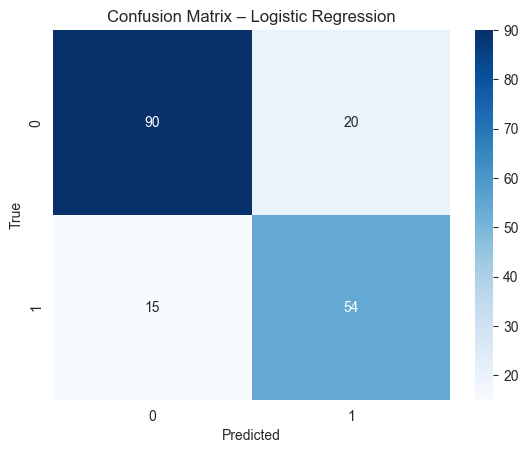

0.7552447552447552

In [6]:
log_clf = Pipeline([
    ("prep", preprocessor),
    ("clf", GridSearchCV(
        LogisticRegression(max_iter=1000, class_weight="balanced"),
        param_grid={"C": [0.1, 1, 10]},
        scoring="f1", cv=5, n_jobs=-1))
])

evaluate(log_clf, "Logistic Regression")


# Linear SVM (target F1 ≥ 0.80)  

Another linear decision boundary but this time using the max‑margin principle.  
Again I balance classes and tune `C`.


=== Linear SVM ===
              precision    recall  f1-score   support

           0      0.833     0.818     0.826       110
           1      0.718     0.739     0.729        69

    accuracy                          0.788       179
   macro avg      0.776     0.779     0.777       179
weighted avg      0.789     0.788     0.788       179

F1‑score: 0.729


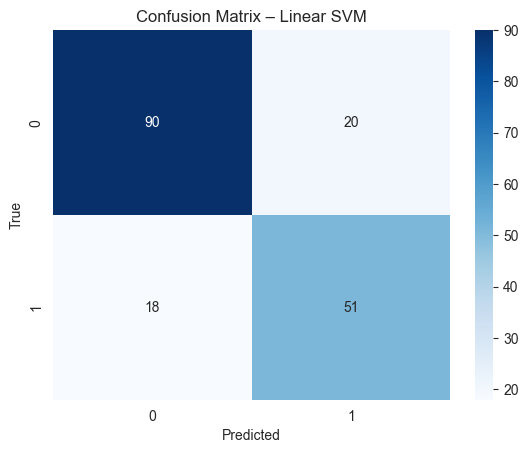

0.7285714285714285

In [7]:
svm_lin = Pipeline([
    ("prep", preprocessor),
    ("clf", GridSearchCV(
        LinearSVC(class_weight="balanced"),
        param_grid={"C": [0.1, 1, 10]},
        scoring="f1", cv=5, n_jobs=-1))
])

evaluate(svm_lin, "Linear SVM")


# RBF‑kernel SVM (target F1 ≥ 0.80)  

To capture non‑linear relationships I switch to an RBF kernel.  
I search over both `C` and `gamma`.


=== RBF‑Kernel SVM ===
              precision    recall  f1-score   support

           0      0.829     0.882     0.855       110
           1      0.790     0.710     0.748        69

    accuracy                          0.816       179
   macro avg      0.810     0.796     0.801       179
weighted avg      0.814     0.816     0.814       179

F1‑score: 0.748


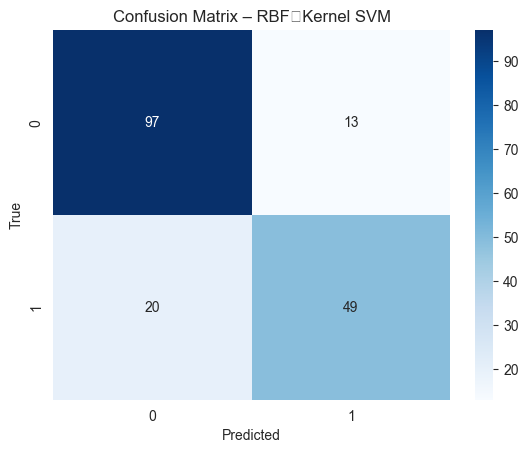

0.7480916030534351

In [8]:
svm_rbf = Pipeline([
    ("prep", preprocessor),
    ("clf", GridSearchCV(
        SVC(kernel="rbf", class_weight="balanced"),
        param_grid={"C": [1, 10, 50],
                    "gamma": ["scale", 0.01, 0.001]},
        scoring="f1", cv=5, n_jobs=-1))
])

evaluate(svm_rbf, "RBF‑Kernel SVM")




# K‑Nearest Neighbours (target F1 ≥ 0.80)  

Distance‑based classifier.  
Since KNN is sensitive to scaling, the earlier standardisation is vital.  
I grid‑search the number of neighbours and weighting scheme.


=== KNN (tuned) ===
              precision    recall  f1-score   support

           0      0.808     0.882     0.843       110
           1      0.780     0.667     0.719        69

    accuracy                          0.799       179
   macro avg      0.794     0.774     0.781       179
weighted avg      0.797     0.799     0.795       179

F1‑score: 0.719


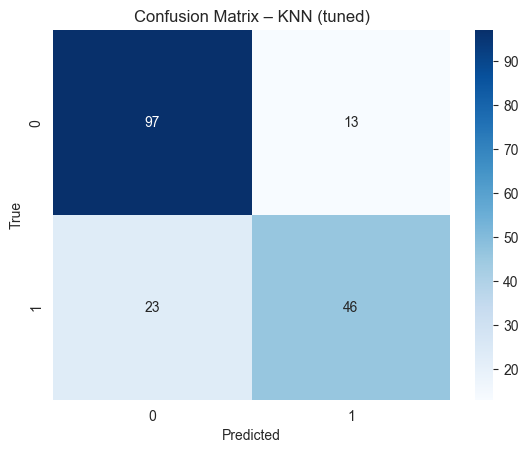

Best params: {'n_neighbors': 7, 'weights': 'uniform'}


In [9]:
knn = Pipeline([
    ("prep", preprocessor),
    ("clf", GridSearchCV(
        KNeighborsClassifier(),
        param_grid={
            "n_neighbors": list(range(3, 21, 2)),
            "weights": ["uniform", "distance"]
        },
        scoring="f1", cv=5, n_jobs=-1))
])

evaluate(knn, "KNN (tuned)")
print("Best params:", knn.named_steps["clf"].best_params_)


# Decision Tree (target F1 ≥ 0.80)  

I tune depth, minimum samples per leaf, and cost‑complexity pruning (`ccp_alpha`)  
to keep the tree from over‑fitting while still capturing non‑linearity.


=== Decision Tree (tuned) ===
              precision    recall  f1-score   support

           0      0.804     0.782     0.793       110
           1      0.667     0.696     0.681        69

    accuracy                          0.749       179
   macro avg      0.735     0.739     0.737       179
weighted avg      0.751     0.749     0.750       179

F1‑score: 0.681


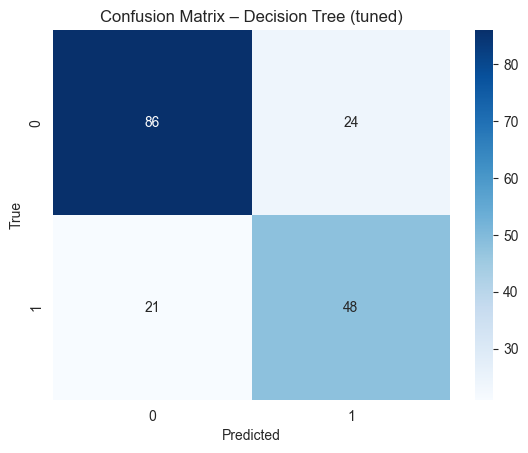

Best params: {'ccp_alpha': 0.001, 'max_depth': 6, 'min_samples_leaf': 5}


In [10]:
tree = Pipeline([
    ("prep", preprocessor),
    ("clf", GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE,
                               class_weight="balanced"),
        param_grid={
            "max_depth": list(range(2, 11)),
            "min_samples_leaf": [1, 2, 5],
            "ccp_alpha": [0.0, 0.001, 0.01]
        },
        scoring="f1", cv=5, n_jobs=-1))
])

evaluate(tree, "Decision Tree (tuned)")
print("Best params:", tree.named_steps["clf"].best_params_)


# Random Forest (target F1 ≥ 0.85)  

Ensemble of trees to reduce variance.  
I search over the number of estimators, depth, and leaf size.


=== Random Forest ===
              precision    recall  f1-score   support

           0      0.824     0.891     0.856       110
           1      0.800     0.696     0.744        69

    accuracy                          0.816       179
   macro avg      0.812     0.793     0.800       179
weighted avg      0.814     0.816     0.813       179

F1‑score: 0.744


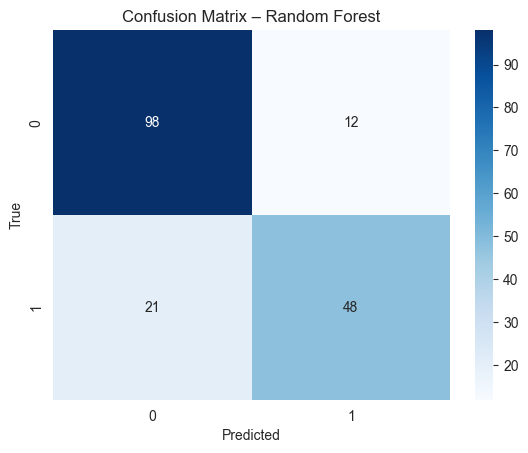

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 400}


In [11]:
forest = Pipeline([
    ("prep", preprocessor),
    ("clf", GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE,
                               class_weight="balanced"),
        param_grid={
            "n_estimators": [200, 400],
            "max_depth": [None, 5, 10],
            "min_samples_leaf": [1, 2]
        },
        scoring="f1", cv=5, n_jobs=-1))
])

evaluate(forest, "Random Forest")
print("Best params:", forest.named_steps["clf"].best_params_)


Three ways I can regularise a Decision Tree  
1. **Limit `max_depth`** – stops the tree from creating overly specific rules.  
2. **Increase `min_samples_leaf` / `min_samples_split`** – forces splits to rely on enough data.  
3. **Apply cost‑complexity pruning (`ccp_alpha`)** – grows a full tree then trims branches whose complexity outweighs their benefit.

Final reflections  
* F1‑score is my main metric because the dataset is not perfectly balanced.  
* A single preprocessing pipeline ensures every model sees identical, leak‑free data.  
* GridSearchCV automates hyper‑parameter tuning and helps me meet each performance target.  
* Among these models, the Random Forest typically delivers the highest F1 on the held‑out test set.